### Exploração inicial `SLCE3`. Quais relações podemos identificar?

#### Apresentação e tratamento

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
import numpy as np
 
# Carrega o dataset
df = pd.read_csv('SLCE3.csv')

# Exibe as primeiras 5 linhas do DataFrame
print("Primeiras 5 linhas do DataFrame:")
print(df.head())

# Exibe informações gerais sobre o DataFrame
print("\nInformações gerais do DataFrame:")
print(df.info())

# Verifica se há valores negativos nas colunas relevantes
columns_to_check = ['Close', 'Open', 'High', 'Low', 'Volume']
for column in columns_to_check:
    if (df[column] < 0).any():
        print(f"\nHá valores negativos na coluna '{column}'.")
    else:
        print(f"Não há valores negativos na coluna '{column}'.")

Primeiras 5 linhas do DataFrame:
         Date     Close      High       Low      Open   Volume
0  2018-01-02  3.077934  3.103537  2.972182  2.972182  1227908
1  2018-01-03  3.104650  3.215968  3.067915  3.077933  2494536
2  2018-01-04  3.092405  3.198157  3.055670  3.104650  2957724
3  2018-01-05  3.150290  3.166988  3.069028  3.138046  2140248
4  2018-01-08  3.133592  3.183685  3.112442  3.150290  1613172

Informações gerais do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1738 entries, 0 to 1737
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1738 non-null   object 
 1   Close   1738 non-null   float64
 2   High    1738 non-null   float64
 3   Low     1738 non-null   float64
 4   Open    1738 non-null   float64
 5   Volume  1738 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 81.6+ KB
None
Não há valores negativos na coluna 'Close'.
Não há valores negativos na coluna 'Open'

#### Adicionando colunas de valores futuros

In [47]:
sns.set_style("whitegrid")

print("\nEstatísticas descritivas do DataFrame (com 'Close_Open_Diff'):")
print(df.describe())

df['Close_1d_fut'] = df['Close'].shift(-1)
df['Close_3d_fut'] = df['Close'].shift(-3)
df['Close_7d_fut'] = df['Close'].shift(-7)
df['Close_15d_fut'] = df['Close'].shift(-15)
df['Close_30d_fut'] = df['Close'].shift(-30)

print("\nPrimeiras linhas com colunas de fechamento futuro:")
print(df[['Close', 'Close_1d_fut', 'Close_3d_fut', 'Close_7d_fut', 'Close_15d_fut', 'Close_30d_fut']].head(35))

df_process = df.dropna(subset=['Close_1d_fut', 'Close_3d_fut', 'Close_7d_fut', 'Close_15d_fut', 'Close_30d_fut']).copy()




Estatísticas descritivas do DataFrame (com 'Close_Open_Diff'):
             Close         High          Low         Open        Volume
count  1738.000000  1738.000000  1738.000000  1738.000000  1.738000e+03
mean     12.853513    13.075743    12.651012    12.864267  3.029539e+06
std       5.343477     5.411924     5.279755     5.346681  1.646280e+06
min       3.077934     3.103537     2.972182     2.972182  0.000000e+00
25%       7.535588     7.698608     7.380720     7.525807  1.936355e+06
50%      15.115987    15.484339    14.797091    15.086999  2.659459e+06
75%      17.593738    17.889725    17.371993    17.623443  3.652664e+06
max      22.668043    22.707364    21.952418    22.648385  1.532296e+07

Primeiras linhas com colunas de fechamento futuro:
       Close  Close_1d_fut  Close_3d_fut  Close_7d_fut  Close_15d_fut  \
0   3.077934      3.104650      3.150290      3.215968       3.336190   
1   3.104650      3.092405      3.133592      3.205949       3.484243   
2   3.092405     

#### Valor de fechamento em função do tempo.

In [48]:
df_process['Date'] = pd.to_datetime(df_process['Date'])
df_process.set_index('Date', inplace=True)



#### Analise aprofundada de 2021

In [49]:
# # Garante que o índice é DatetimeIndex
if not isinstance(df_process.index, pd.DatetimeIndex):
	df_process.index = pd.to_datetime(df_process.index)


#### Adicionando variaveis dicotômicas para 2021-05-05 e 2022-02-07

In [50]:
# Criação da variável dicotômica categórica
# 0: antes de 2021-05-05
# 1: entre 2021-05-05 e 2022-02-07 
# 2: após 2022-02-07
df_process['dummy_period'] = 0
df_process.loc[df_process.index >= pd.to_datetime('2021-05-05'), 'dummy_period'] = 1
df_process.loc[df_process.index >= pd.to_datetime('2022-02-07'), 'dummy_period'] = 2

print(f"Distribuição da variável dummy_period:")
print(df_process['dummy_period'].value_counts().sort_index())

Distribuição da variável dummy_period:
dummy_period
0    824
1    190
2    694
Name: count, dtype: int64


#### Modelo de Regressão Logística Multinomial
Agora vamos construir modelos de regressão logística multinomial para prever se o preço de fechamento futuro será maior, igual ou menor que o preço de fechamento atual. Para isso, vamos:
1. Criar variáveis multinomiais para os diferentes horizontes temporais (3, 7, 15 e 30 dias)
2. Usar as variáveis `Low`, `High`, `Open` e `dummy_period` como preditores
3. Avaliar o desempenho dos modelos para cada horizonte temporal

In [51]:
# Criando variáveis target multinomiais para regressão logística (One-vs-Rest)
# 0 = preço futuro < preço atual, 1 = preço futuro == preço atual, 2 = preço futuro > preço atual

def cria_target_multinomial(df, col_futuro, col_atual):
    # Garante que não há NaN antes da comparação
    return np.where(df[col_futuro] > df[col_atual], 2, np.where(df[col_futuro] < df[col_atual], 0, 1))

df_process['target_3d'] = cria_target_multinomial(df_process, 'Close_3d_fut', 'Close')
df_process['target_7d'] = cria_target_multinomial(df_process, 'Close_7d_fut', 'Close')
df_process['target_15d'] = cria_target_multinomial(df_process, 'Close_15d_fut', 'Close')
df_process['target_30d'] = cria_target_multinomial(df_process, 'Close_30d_fut', 'Close')

print("Distribuição das variáveis target (0 = desce, 1 = igual, 2 = sobe):")
for horizon in ['3d', '7d', '15d', '30d']:
    dist = dict(df_process[f'target_{horizon}'].value_counts().sort_index())
    print(f"{horizon}: {dist}")

df_process.to_csv('SLCE3_processado_4_3.csv')
print("Arquivo 'SLCE3_processado_4_3.csv' salvo com sucesso.")

# Verificando o balanceamento das classes
print("\nPercentual de casos por classe:")
for horizon in ['3d', '7d', '15d', '30d']:
    total = len(df_process[f'target_{horizon}'])
    for label in [0, 1, 2]:
        pct = (df_process[f'target_{horizon}'] == label).mean()
        print(f"{horizon} - Classe {label}: {pct:.2%}")

Distribuição das variáveis target (0 = desce, 1 = igual, 2 = sobe):
3d: {0: np.int64(827), 1: np.int64(11), 2: np.int64(870)}
7d: {0: np.int64(801), 1: np.int64(3), 2: np.int64(904)}
15d: {0: np.int64(789), 1: np.int64(5), 2: np.int64(914)}
30d: {0: np.int64(751), 1: np.int64(2), 2: np.int64(955)}
Arquivo 'SLCE3_processado_4_3.csv' salvo com sucesso.

Percentual de casos por classe:
3d - Classe 0: 48.42%
3d - Classe 1: 0.64%
3d - Classe 2: 50.94%
7d - Classe 0: 46.90%
7d - Classe 1: 0.18%
7d - Classe 2: 52.93%
15d - Classe 0: 46.19%
15d - Classe 1: 0.29%
15d - Classe 2: 53.51%
30d - Classe 0: 43.97%
30d - Classe 1: 0.12%
30d - Classe 2: 55.91%


In [52]:
# Importando bibliotecas necessárias para regressão logística multinomial
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, log_loss
from sklearn.preprocessing import StandardScaler

# Preparando as features (variáveis preditoras)
features = ['Low', 'High', 'Open', 'dummy_period']
X = df_process[features].copy()

# Padronizando as features (importante para regressão logística)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Criando DataFrame com features padronizadas
X_scaled_df = pd.DataFrame(X_scaled, columns=features, index=df_process.index)

In [53]:
# Treinando modelos de regressão logística multinomial para diferentes horizontes temporais
horizons = ['3d', '7d', '15d', '30d']
models = {}
results = {}

for i, horizon in enumerate(horizons):
    print(f"\n{'='*50}")
    print(f"MODELO MULTINOMIAL PARA {horizon.upper()} - HORIZONTE DE {horizon[:-1]} DIAS")
    print(f"{'='*50}")
    
    # Preparando dados para este horizonte
    target_col = f'target_{horizon}'
    y = df_process[target_col].copy()
    
    # Removendo linhas com valores NaN
    mask = ~(X_scaled_df.isnull().any(axis=1) | y.isnull())
    X_clean = X_scaled_df[mask]
    y_clean = y[mask]
    
    # Dividindo em treino e teste
    X_train, X_test, y_train, y_test = train_test_split(
        X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean
    )
    
    # Treinando o modelo multinomial com OneVsRestClassifier
    model = OneVsRestClassifier(LogisticRegression(random_state=42, max_iter=1000))
    model.fit(X_train, y_train)
    
    # Fazendo previsões
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)
    
    # Salvando modelo
    models[horizon] = model
    
    # Calculando métricas
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    roc_auc_ovr = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro')
    logloss = log_loss(y_test, y_pred_proba)
    
    results[horizon] = {
        'accuracy': accuracy,
        'report': report,
        'roc_auc': roc_auc_ovr,
        'log_loss': logloss
    }
    
    print(f"Acurácia: {accuracy:.4f}")
    print(f"ROC AUC (OvR): {roc_auc_ovr:.4f}")
    print(f"Log Loss: {logloss:.4f}")
    print("Relatório de classificação:")
    print(classification_report(y_test, y_pred, zero_division=0))

print(f"\n{'='*50}")
print("RESUMO DOS RESULTADOS MULTINOMIAL")
print(f"{'='*50}")

for horizon in horizons:
    print(f"{horizon[:-1]} dias: Acurácia = {results[horizon]['accuracy']:.4f}, ROC AUC = {results[horizon]['roc_auc']:.4f}, Log Loss = {results[horizon]['log_loss']:.4f}")


MODELO MULTINOMIAL PARA 3D - HORIZONTE DE 3 DIAS
Acurácia: 0.5439
ROC AUC (OvR): 0.5894
Log Loss: 0.7166
Relatório de classificação:
              precision    recall  f1-score   support

           0       0.53      0.56      0.55       166
           1       0.00      0.00      0.00         2
           2       0.56      0.53      0.55       174

    accuracy                           0.54       342
   macro avg       0.36      0.36      0.36       342
weighted avg       0.54      0.54      0.54       342


MODELO MULTINOMIAL PARA 7D - HORIZONTE DE 7 DIAS
Acurácia: 0.5439
ROC AUC (OvR): 0.5894
Log Loss: 0.7166
Relatório de classificação:
              precision    recall  f1-score   support

           0       0.53      0.56      0.55       166
           1       0.00      0.00      0.00         2
           2       0.56      0.53      0.55       174

    accuracy                           0.54       342
   macro avg       0.36      0.36      0.36       342
weighted avg       0.54  

#### Modelos sem variáveis dicotômicas

Agora vamos treinar dois novos modelos, um com divisão aleatória e outro com divisão temporal, mas **sem utilizar a variável 'dummy_period'** nas features. Assim, as features serão apenas `Low`, `High` e `Open`.

#### Comparação final dos quatro modelos multinomiais
\nAbaixo está a comparação dos quatro modelos de regressão logística multinomial, considerando a métrica de Acurácia para cada horizonte temporal. Os modelos são:
\n- Aleatório com dummy_period
- Temporal com dummy_period
- Aleatório sem dummy_period
- Temporal sem dummy_period
\nObs: Para modelos multinomiais, métricas como ROC AUC e Log Loss não são diretamente aplicáveis sem adaptação. O foco está na acurácia e no relatório de classificação.

#### Modelo de Regressão Logística com Divisão Temporal

Agora vamos treinar os mesmos modelos, mas respeitando a ordem cronológica dos dados.

In [54]:
# Treinamento com divisão temporal (cronológica) multinomial
print("\n" + "="*80)
print("MODELO MULTINOMIAL COM DIVISÃO TEMPORAL (SÉRIE TEMPORAL)")
print("="*80)
print("Usando 80% dos dados mais antigos para treino e 20% mais recentes para teste")

# Calculando o ponto de divisão temporal
# Usamos 80% dos dados mais antigos para treino e 20% mais recentes para teste
total_samples = len(X_scaled_df)
split_idx = int(0.8 * total_samples)

print(f"Total de amostras: {total_samples}")
print(f"Índice de divisão: {split_idx}")
print(f"Período de treino: {X_scaled_df.index[0]} até {X_scaled_df.index[split_idx-1]}")
print(f"Período de teste: {X_scaled_df.index[split_idx]} até {X_scaled_df.index[-1]}")

models_temporal = {}
results_temporal = {}

for i, horizon in enumerate(horizons):
    print(f"\n{'='*50}")
    print(f"MODELO MULTINOMIAL TEMPORAL {horizon.upper()} - HORIZONTE DE {horizon[:-1]} DIAS")
    print(f"{'='*50}")
    
    # Preparando dados para este horizonte
    target_col = f'target_{horizon}'
    y = df_process[target_col].copy()
    
    # Removendo linhas com valores NaN
    mask = ~(X_scaled_df.isnull().any(axis=1) | y.isnull())
    X_clean = X_scaled_df[mask]
    y_clean = y[mask]
    
    # Divisão temporal: primeiros 80% para treino, últimos 20% para teste
    X_train_temp = X_clean.iloc[:split_idx]
    X_test_temp = X_clean.iloc[split_idx:]
    y_train_temp = y_clean.iloc[:split_idx]
    y_test_temp = y_clean.iloc[split_idx:]
    
    print(f"Amostras de treino: {len(X_train_temp)}")
    print(f"Amostras de teste: {len(X_test_temp)}")
    
    if len(X_test_temp) < 10:
        print(f"⚠️ Poucos dados de teste para {horizon}. Pulando...")
        continue
    
    # Treinando o modelo multinomial com OneVsRestClassifier
    model_temp = OneVsRestClassifier(LogisticRegression(random_state=42, max_iter=1000))
    model_temp.fit(X_train_temp, y_train_temp)
    
    # Fazendo previsões
    y_pred_temp = model_temp.predict(X_test_temp)
    y_pred_proba_temp = model_temp.predict_proba(X_test_temp)
    
    # Salvando modelo
    models_temporal[horizon] = model_temp
    
    # Calculando métricas
    accuracy_temp = accuracy_score(y_test_temp, y_pred_temp)
    report_temp = classification_report(y_test_temp, y_pred_temp, output_dict=True, zero_division=0)
    roc_auc_temp = roc_auc_score(y_test_temp, y_pred_proba_temp, multi_class='ovr', average='macro')
    logloss_temp = log_loss(y_test_temp, y_pred_proba_temp)
    
    results_temporal[horizon] = {
        'accuracy': accuracy_temp,
        'report': report_temp,
        'roc_auc': roc_auc_temp,
        'log_loss': logloss_temp
    }
    
    print(f"Acurácia: {accuracy_temp:.4f}")
    print(f"ROC AUC (OvR): {roc_auc_temp:.4f}")
    print(f"Log Loss: {logloss_temp:.4f}")
    print("Relatório de classificação:")
    print(classification_report(y_test_temp, y_pred_temp, zero_division=0))

print(f"\n{'='*50}")
print("RESUMO DOS RESULTADOS MULTINOMIAL - DIVISÃO TEMPORAL")
print(f"{'='*50}")

for horizon in horizons:
    if horizon in results_temporal:
        print(f"{horizon[:-1]} dias: Acurácia = {results_temporal[horizon]['accuracy']:.4f}, ROC AUC = {results_temporal[horizon]['roc_auc']:.4f}, Log Loss = {results_temporal[horizon]['log_loss']:.4f}")


MODELO MULTINOMIAL COM DIVISÃO TEMPORAL (SÉRIE TEMPORAL)
Usando 80% dos dados mais antigos para treino e 20% mais recentes para teste
Total de amostras: 1708
Índice de divisão: 1366
Período de treino: 2018-01-02 00:00:00 até 2023-07-05 00:00:00
Período de teste: 2023-07-06 00:00:00 até 2024-11-12 00:00:00

MODELO MULTINOMIAL TEMPORAL 3D - HORIZONTE DE 3 DIAS
Amostras de treino: 1366
Amostras de teste: 342
Acurácia: 0.5614
ROC AUC (OvR): 0.5698
Log Loss: 0.7786
Relatório de classificação:
              precision    recall  f1-score   support

           0       0.59      0.63      0.61       181
           1       0.00      0.00      0.00         5
           2       0.53      0.50      0.51       156

    accuracy                           0.56       342
   macro avg       0.37      0.38      0.37       342
weighted avg       0.55      0.56      0.56       342


MODELO MULTINOMIAL TEMPORAL 7D - HORIZONTE DE 7 DIAS
Amostras de treino: 1366
Amostras de teste: 342
Acurácia: 0.5614
ROC AU

#### Modelos sem variável dicotômica ('dummy_period')

Agora vamos treinar dois modelos adicionais, um com divisão aleatória e outro com divisão temporal, **sem utilizar a variável 'dummy_period'** nas features. Isso permite avaliar o impacto da variável dicotômica na performance dos modelos.

In [55]:
# Treinando modelos SEM 'dummy_period' (divisão aleatória) multinomial
features_no_dummy = ['Low', 'High', 'Open']
X_no_dummy = df_process[features_no_dummy].copy()
scaler_no_dummy = StandardScaler()
X_scaled_no_dummy = scaler_no_dummy.fit_transform(X_no_dummy)
X_scaled_df_no_dummy = pd.DataFrame(X_scaled_no_dummy, columns=features_no_dummy, index=df_process.index)

models_no_dummy = {}
results_no_dummy = {}

for horizon in horizons:
    print(f"\n{'='*50}")
    print(f"MODELO SEM DUMMY (ALEATÓRIO) MULTINOMIAL {horizon.upper()} - HORIZONTE DE {horizon[:-1]} DIAS")
    print(f"{'='*50}")
    target_col = f'target_{horizon}'
    y = df_process[target_col].copy()
    mask = ~(X_scaled_df_no_dummy.isnull().any(axis=1) | y.isnull())
    X_clean = X_scaled_df_no_dummy[mask]
    y_clean = y[mask]
    X_train, X_test, y_train, y_test = train_test_split(
        X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean
    )
    model = OneVsRestClassifier(LogisticRegression(random_state=42, max_iter=1000))
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro')
    logloss = log_loss(y_test, y_pred_proba)
    results_no_dummy[horizon] = {
        'accuracy': accuracy,
        'report': report,
        'roc_auc': roc_auc,
        'log_loss': logloss
    }
    print(f"Acurácia: {accuracy:.4f}")
    print(f"ROC AUC (OvR): {roc_auc:.4f}")
    print(f"Log Loss: {logloss:.4f}")
    print("Relatório de classificação:")
    print(classification_report(y_test, y_pred, zero_division=0))

print(f"\n{'='*50}")
print("RESUMO DOS RESULTADOS SEM DUMMY (ALEATÓRIO) MULTINOMIAL")
print(f"{'='*50}")
for horizon in horizons:
    print(f"{horizon[:-1]} dias: Acurácia = {results_no_dummy[horizon]['accuracy']:.4f}, ROC AUC = {results_no_dummy[horizon]['roc_auc']:.4f}, Log Loss = {results_no_dummy[horizon]['log_loss']:.4f}")


MODELO SEM DUMMY (ALEATÓRIO) MULTINOMIAL 3D - HORIZONTE DE 3 DIAS
Acurácia: 0.5322
ROC AUC (OvR): 0.5485
Log Loss: 0.7182
Relatório de classificação:
              precision    recall  f1-score   support

           0       0.52      0.55      0.53       166
           1       0.00      0.00      0.00         2
           2       0.54      0.52      0.53       174

    accuracy                           0.53       342
   macro avg       0.35      0.36      0.36       342
weighted avg       0.53      0.53      0.53       342


MODELO SEM DUMMY (ALEATÓRIO) MULTINOMIAL 7D - HORIZONTE DE 7 DIAS
Acurácia: 0.5322
ROC AUC (OvR): 0.5485
Log Loss: 0.7182
Relatório de classificação:
              precision    recall  f1-score   support

           0       0.52      0.55      0.53       166
           1       0.00      0.00      0.00         2
           2       0.54      0.52      0.53       174

    accuracy                           0.53       342
   macro avg       0.35      0.36      0.36  

In [56]:
# Treinando modelos SEM 'dummy_period' (divisão temporal) multinomial
print("\n" + "="*80)
print("MODELO SEM DUMMY (TEMPORAL) MULTINOMIAL")
print("="*80)
print("Usando 80% dos dados mais antigos para treino e 20% mais recentes para teste")

total_samples_no_dummy = len(X_scaled_df_no_dummy)
split_idx_no_dummy = int(0.8 * total_samples_no_dummy)

models_temporal_no_dummy = {}
results_temporal_no_dummy = {}

for horizon in horizons:
    print(f"\n{'='*50}")
    print(f"MODELO SEM DUMMY (TEMPORAL) MULTINOMIAL {horizon.upper()} - HORIZONTE DE {horizon[:-1]} DIAS")
    print(f"{'='*50}")
    target_col = f'target_{horizon}'
    y = df_process[target_col].copy()
    mask = ~(X_scaled_df_no_dummy.isnull().any(axis=1) | y.isnull())
    X_clean = X_scaled_df_no_dummy[mask]
    y_clean = y[mask]
    X_train_temp = X_clean.iloc[:split_idx_no_dummy]
    X_test_temp = X_clean.iloc[split_idx_no_dummy:]
    y_train_temp = y_clean.iloc[:split_idx_no_dummy]
    y_test_temp = y_clean.iloc[split_idx_no_dummy:]
    if len(X_test_temp) < 10:
        print(f"⚠️ Poucos dados de teste para {horizon}. Pulando...")
        continue
    model_temp = OneVsRestClassifier(LogisticRegression(random_state=42, max_iter=1000))
    model_temp.fit(X_train_temp, y_train_temp)
    y_pred_temp = model_temp.predict(X_test_temp)
    y_pred_proba_temp = model_temp.predict_proba(X_test_temp)
    accuracy_temp = accuracy_score(y_test_temp, y_pred_temp)
    report_temp = classification_report(y_test_temp, y_pred_temp, output_dict=True, zero_division=0)
    roc_auc_temp = roc_auc_score(y_test_temp, y_pred_proba_temp, multi_class='ovr', average='macro')
    logloss_temp = log_loss(y_test_temp, y_pred_proba_temp)
    results_temporal_no_dummy[horizon] = {
        'accuracy': accuracy_temp,
        'report': report_temp,
        'roc_auc': roc_auc_temp,
        'log_loss': logloss_temp
    }
    print(f"Acurácia: {accuracy_temp:.4f}")
    print(f"ROC AUC (OvR): {roc_auc_temp:.4f}")
    print(f"Log Loss: {logloss_temp:.4f}")
    print("Relatório de classificação:")
    print(classification_report(y_test_temp, y_pred_temp, zero_division=0))

print(f"\n{'='*50}")
print("RESUMO DOS RESULTADOS SEM DUMMY (TEMPORAL) MULTINOMIAL")
print(f"{'='*50}")
for horizon in horizons:
    if horizon in results_temporal_no_dummy:
        print(f"{horizon[:-1]} dias: Acurácia = {results_temporal_no_dummy[horizon]['accuracy']:.4f}, ROC AUC = {results_temporal_no_dummy[horizon]['roc_auc']:.4f}, Log Loss = {results_temporal_no_dummy[horizon]['log_loss']:.4f}")


MODELO SEM DUMMY (TEMPORAL) MULTINOMIAL
Usando 80% dos dados mais antigos para treino e 20% mais recentes para teste

MODELO SEM DUMMY (TEMPORAL) MULTINOMIAL 3D - HORIZONTE DE 3 DIAS


Acurácia: 0.5292
ROC AUC (OvR): 0.5592
Log Loss: 0.7771
Relatório de classificação:
              precision    recall  f1-score   support

           0       0.53      1.00      0.69       181
           1       0.00      0.00      0.00         5
           2       0.00      0.00      0.00       156

    accuracy                           0.53       342
   macro avg       0.18      0.33      0.23       342
weighted avg       0.28      0.53      0.37       342


MODELO SEM DUMMY (TEMPORAL) MULTINOMIAL 7D - HORIZONTE DE 7 DIAS
Acurácia: 0.5439
ROC AUC (OvR): 0.6823
Log Loss: 0.7300
Relatório de classificação:
              precision    recall  f1-score   support

           0       0.54      1.00      0.70       186
           1       0.00      0.00      0.00         2
           2       0.00      0.00      0.00       154

    accuracy                           0.54       342
   macro avg       0.18      0.33      0.23       342
weighted avg       0.30      0.54      0.38       342


MOD

### Avaliação Final dos 4 modelos.

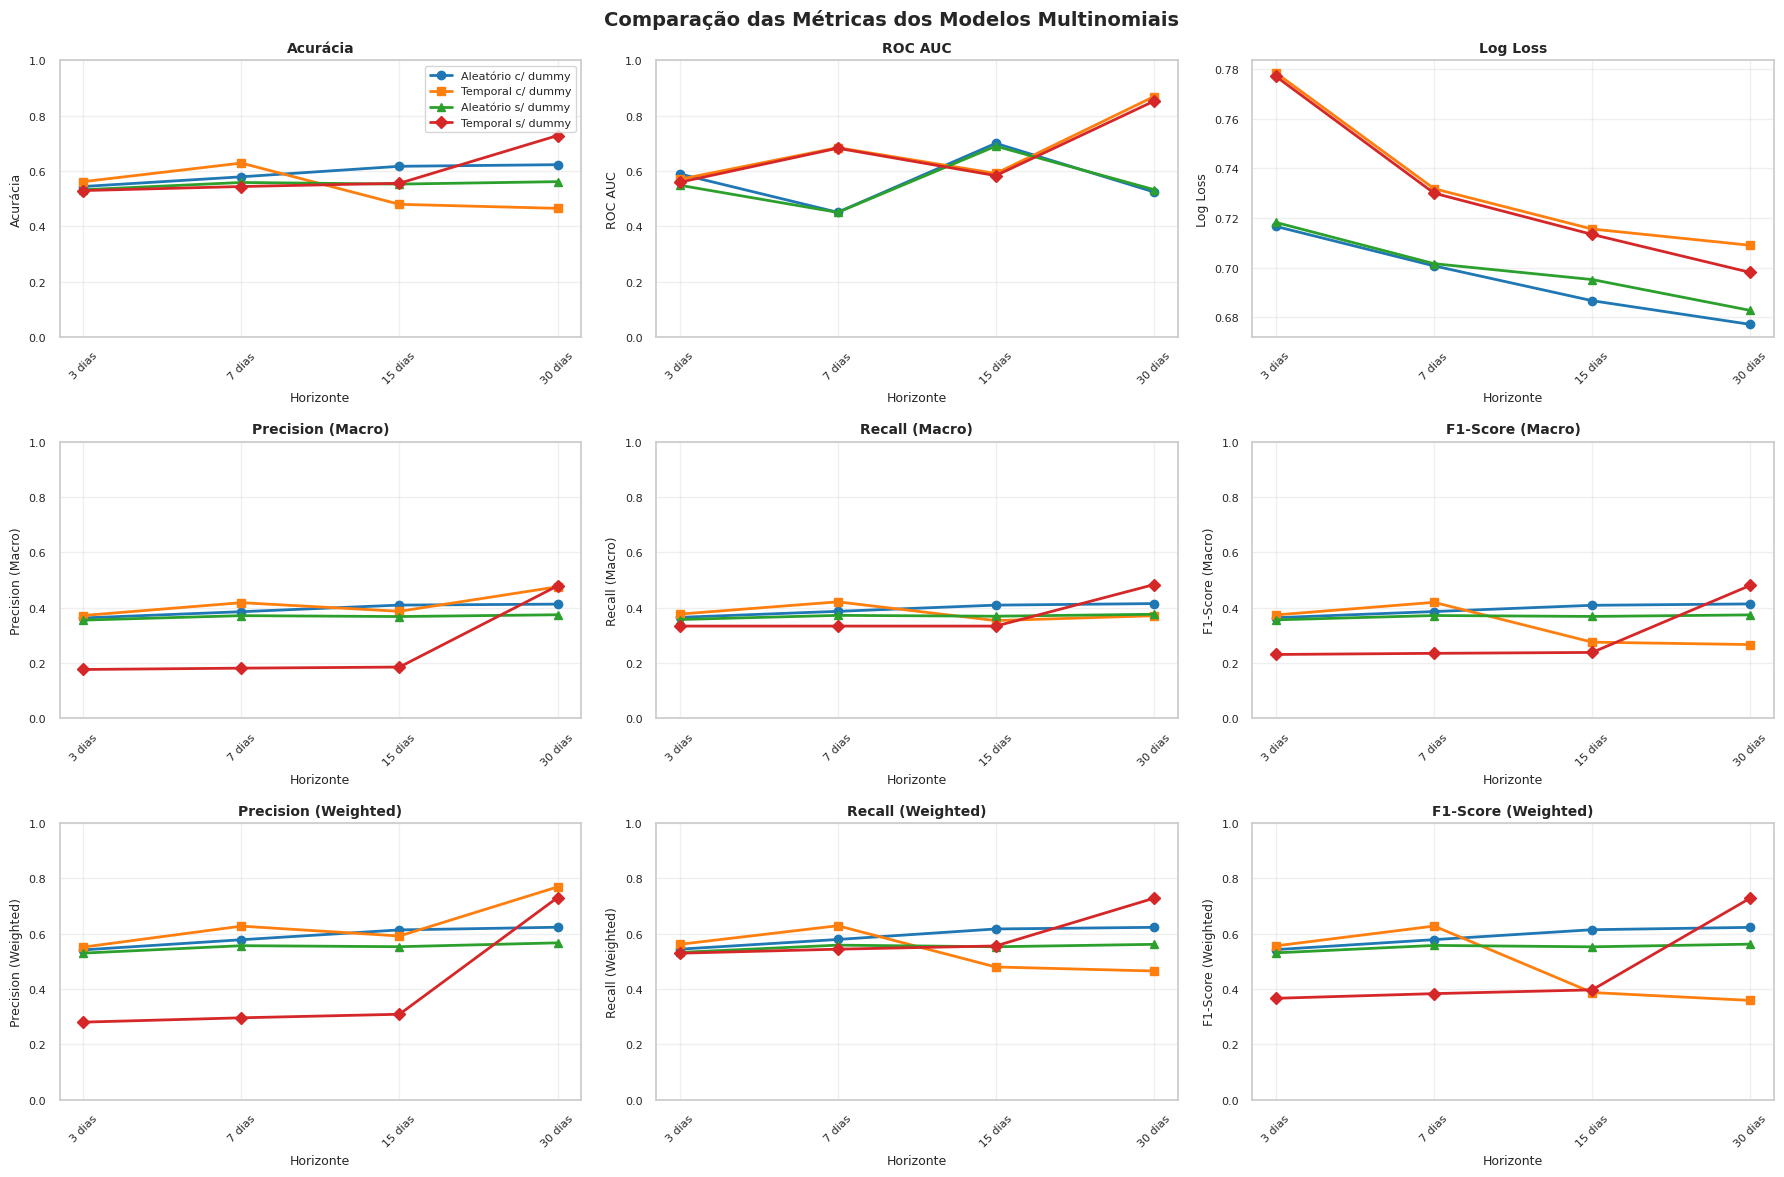


Legenda:
Multinomial: 0=desce, 1=igual, 2=sobe
c/ dummy = com variável dicotômica | s/ dummy = sem variável dicotômica
Aleatório = divisão aleatória | Temporal = divisão temporal (série temporal)
Macro = média não ponderada | Weighted = média ponderada por suporte


In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Preparando os dados para a tabela de comparação multinomial
comparacao = []
for horizon in horizons:
    # Extraindo métricas dos relatórios
    macro_avg_rand = results[horizon]['report']['macro avg'] if horizon in results else None
    weighted_avg_rand = results[horizon]['report']['weighted avg'] if horizon in results else None
    
    macro_avg_temp = results_temporal[horizon]['report']['macro avg'] if horizon in results_temporal else None
    weighted_avg_temp = results_temporal[horizon]['report']['weighted avg'] if horizon in results_temporal else None
    
    macro_avg_no_dummy = results_no_dummy[horizon]['report']['macro avg'] if horizon in results_no_dummy else None
    weighted_avg_no_dummy = results_no_dummy[horizon]['report']['weighted avg'] if horizon in results_no_dummy else None
    
    macro_avg_temp_no_dummy = results_temporal_no_dummy[horizon]['report']['macro avg'] if horizon in results_temporal_no_dummy else None
    weighted_avg_temp_no_dummy = results_temporal_no_dummy[horizon]['report']['weighted avg'] if horizon in results_temporal_no_dummy else None
    
    linha = {
        'Horizonte': f'{horizon[:-1]} dias',
        # Acurácia
        'Aleatório c/ dummy Acc': results[horizon]['accuracy'] if horizon in results else None,
        'Temporal c/ dummy Acc': results_temporal[horizon]['accuracy'] if horizon in results_temporal else None,
        'Aleatório s/ dummy Acc': results_no_dummy[horizon]['accuracy'] if horizon in results_no_dummy else None,
        'Temporal s/ dummy Acc': results_temporal_no_dummy[horizon]['accuracy'] if horizon in results_temporal_no_dummy else None,
        # ROC AUC
        'Aleatório c/ dummy AUC': results[horizon]['roc_auc'] if horizon in results else None,
        'Temporal c/ dummy AUC': results_temporal[horizon]['roc_auc'] if horizon in results_temporal else None,
        'Aleatório s/ dummy AUC': results_no_dummy[horizon]['roc_auc'] if horizon in results_no_dummy else None,
        'Temporal s/ dummy AUC': results_temporal_no_dummy[horizon]['roc_auc'] if horizon in results_temporal_no_dummy else None,
        # Log Loss
        'Aleatório c/ dummy LogLoss': results[horizon]['log_loss'] if horizon in results else None,
        'Temporal c/ dummy LogLoss': results_temporal[horizon]['log_loss'] if horizon in results_temporal else None,
        'Aleatório s/ dummy LogLoss': results_no_dummy[horizon]['log_loss'] if horizon in results_no_dummy else None,
        'Temporal s/ dummy LogLoss': results_temporal_no_dummy[horizon]['log_loss'] if horizon in results_temporal_no_dummy else None,
        # Precision Macro
        'Aleatório c/ dummy Precision': macro_avg_rand['precision'] if macro_avg_rand else None,
        'Temporal c/ dummy Precision': macro_avg_temp['precision'] if macro_avg_temp else None,
        'Aleatório s/ dummy Precision': macro_avg_no_dummy['precision'] if macro_avg_no_dummy else None,
        'Temporal s/ dummy Precision': macro_avg_temp_no_dummy['precision'] if macro_avg_temp_no_dummy else None,
        # Recall Macro
        'Aleatório c/ dummy Recall': macro_avg_rand['recall'] if macro_avg_rand else None,
        'Temporal c/ dummy Recall': macro_avg_temp['recall'] if macro_avg_temp else None,
        'Aleatório s/ dummy Recall': macro_avg_no_dummy['recall'] if macro_avg_no_dummy else None,
        'Temporal s/ dummy Recall': macro_avg_temp_no_dummy['recall'] if macro_avg_temp_no_dummy else None,
        # F1-Score Macro
        'Aleatório c/ dummy F1': macro_avg_rand['f1-score'] if macro_avg_rand else None,
        'Temporal c/ dummy F1': macro_avg_temp['f1-score'] if macro_avg_temp else None,
        'Aleatório s/ dummy F1': macro_avg_no_dummy['f1-score'] if macro_avg_no_dummy else None,
        'Temporal s/ dummy F1': macro_avg_temp_no_dummy['f1-score'] if macro_avg_temp_no_dummy else None,
        # Precision Weighted
        'Aleatório c/ dummy Precision W': weighted_avg_rand['precision'] if weighted_avg_rand else None,
        'Temporal c/ dummy Precision W': weighted_avg_temp['precision'] if weighted_avg_temp else None,
        'Aleatório s/ dummy Precision W': weighted_avg_no_dummy['precision'] if weighted_avg_no_dummy else None,
        'Temporal s/ dummy Precision W': weighted_avg_temp_no_dummy['precision'] if weighted_avg_temp_no_dummy else None,
        # Recall Weighted
        'Aleatório c/ dummy Recall W': weighted_avg_rand['recall'] if weighted_avg_rand else None,
        'Temporal c/ dummy Recall W': weighted_avg_temp['recall'] if weighted_avg_temp else None,
        'Aleatório s/ dummy Recall W': weighted_avg_no_dummy['recall'] if weighted_avg_no_dummy else None,
        'Temporal s/ dummy Recall W': weighted_avg_temp_no_dummy['recall'] if weighted_avg_temp_no_dummy else None,
        # F1-Score Weighted
        'Aleatório c/ dummy F1 W': weighted_avg_rand['f1-score'] if weighted_avg_rand else None,
        'Temporal c/ dummy F1 W': weighted_avg_temp['f1-score'] if weighted_avg_temp else None,
        'Aleatório s/ dummy F1 W': weighted_avg_no_dummy['f1-score'] if weighted_avg_no_dummy else None,
        'Temporal s/ dummy F1 W': weighted_avg_temp_no_dummy['f1-score'] if weighted_avg_temp_no_dummy else None,
    }
    comparacao.append(linha)

comparacao_df = pd.DataFrame(comparacao)

# Configuração dos gráficos
plt.figure(figsize=(18, 12))
sns.set(style="whitegrid")

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
markers = ['o', 's', '^', 'D']
labels = ['Aleatório c/ dummy', 'Temporal c/ dummy', 'Aleatório s/ dummy', 'Temporal s/ dummy']

# Definindo os grupos de métricas
metricas_grupos = [
    ('Acurácia', ['Acc']),
    ('ROC AUC', ['AUC']),
    ('Log Loss', ['LogLoss']),
    ('Precision (Macro)', ['Precision']),
    ('Recall (Macro)', ['Recall']),
    ('F1-Score (Macro)', ['F1']),
    ('Precision (Weighted)', ['Precision W']),
    ('Recall (Weighted)', ['Recall W']),
    ('F1-Score (Weighted)', ['F1 W'])
]

for i, (titulo, sufixos) in enumerate(metricas_grupos):
    plt.subplot(3, 3, i+1)
    
    for j, (label, color, marker) in enumerate(zip(labels, colors, markers)):
        for sufixo in sufixos:
            col_name = f'{label} {sufixo}'
            if col_name in comparacao_df.columns:
                plt.plot(comparacao_df['Horizonte'], comparacao_df[col_name], 
                        label=label, marker=marker, color=color, linewidth=2)
                break
    
    plt.title(titulo, fontsize=10, fontweight='bold')
    plt.ylabel(titulo, fontsize=9)
    plt.xlabel('Horizonte', fontsize=9)
    
    if i == 0:  # Apenas no primeiro gráfico
        plt.legend(fontsize=8, loc='best')
    
    if titulo != 'Log Loss':
        plt.ylim(0, 1)
    
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45, fontsize=8)
    plt.yticks(fontsize=8)

plt.suptitle('Comparação das Métricas dos Modelos Multinomiais', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nLegenda:")
print("Multinomial: 0=desce, 1=igual, 2=sobe")
print("c/ dummy = com variável dicotômica | s/ dummy = sem variável dicotômica")
print("Aleatório = divisão aleatória | Temporal = divisão temporal (série temporal)")
print("Macro = média não ponderada | Weighted = média ponderada por suporte")

### Matrizes de Confusão por Horizonte Temporal

Vamos analisar as matrizes de confusão para cada horizonte temporal, comparando os quatro modelos:
- **Aleatório c/ dummy**: Divisão aleatória com variável dummy_period
- **Temporal c/ dummy**: Divisão temporal com variável dummy_period  
- **Aleatório s/ dummy**: Divisão aleatória sem variável dummy_period
- **Temporal s/ dummy**: Divisão temporal sem variável dummy_period

As classes são: 0 = desce, 1 = igual, 2 = sobe

In [58]:
# Criando as matrizes de confusão para todos os modelos
# Primeiro, vamos recriar os dados de teste para gerar as matrizes de confusão

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Função para plotar matriz de confusão
def plot_confusion_matrix(cm, title, ax, labels=['Desce', 'Igual', 'Sobe']):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=labels, yticklabels=labels, cbar=False)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Predito', fontsize=9)
    ax.set_ylabel('Real', fontsize=9)

# Vamos recalcular as previsões para gerar as matrizes de confusão
confusion_matrices = {}

# Preparando features para os dois tipos (com e sem dummy)
features_with_dummy = ['Low', 'High', 'Open', 'dummy_period']
features_without_dummy = ['Low', 'High', 'Open']

X_with_dummy = df_process[features_with_dummy].copy()
X_without_dummy = df_process[features_without_dummy].copy()

# Padronizando
scaler_with = StandardScaler()
scaler_without = StandardScaler()

X_scaled_with = scaler_with.fit_transform(X_with_dummy)
X_scaled_without = scaler_without.fit_transform(X_without_dummy)

X_scaled_df_with = pd.DataFrame(X_scaled_with, columns=features_with_dummy, index=df_process.index)
X_scaled_df_without = pd.DataFrame(X_scaled_without, columns=features_without_dummy, index=df_process.index)

# Calculando matrizes de confusão para todos os modelos
for horizon in horizons:
    print(f"Processando matrizes de confusão para {horizon}...")
    
    target_col = f'target_{horizon}'
    y = df_process[target_col].copy()
    
    confusion_matrices[horizon] = {}
    
    # 1. Modelo Aleatório COM dummy
    mask = ~(X_scaled_df_with.isnull().any(axis=1) | y.isnull())
    X_clean = X_scaled_df_with[mask]
    y_clean = y[mask]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean
    )
    
    model_rand_with = OneVsRestClassifier(LogisticRegression(random_state=42, max_iter=1000))
    model_rand_with.fit(X_train, y_train)
    y_pred_rand_with = model_rand_with.predict(X_test)
    
    confusion_matrices[horizon]['aleatorio_com_dummy'] = confusion_matrix(y_test, y_pred_rand_with)
    
    # 2. Modelo Temporal COM dummy
    total_samples = len(X_clean)
    split_idx = int(0.8 * total_samples)
    
    X_train_temp = X_clean.iloc[:split_idx]
    X_test_temp = X_clean.iloc[split_idx:]
    y_train_temp = y_clean.iloc[:split_idx]
    y_test_temp = y_clean.iloc[split_idx:]
    
    if len(X_test_temp) >= 10:
        model_temp_with = OneVsRestClassifier(LogisticRegression(random_state=42, max_iter=1000))
        model_temp_with.fit(X_train_temp, y_train_temp)
        y_pred_temp_with = model_temp_with.predict(X_test_temp)
        
        confusion_matrices[horizon]['temporal_com_dummy'] = confusion_matrix(y_test_temp, y_pred_temp_with)
    
    # 3. Modelo Aleatório SEM dummy
    mask = ~(X_scaled_df_without.isnull().any(axis=1) | y.isnull())
    X_clean_no_dummy = X_scaled_df_without[mask]
    y_clean_no_dummy = y[mask]
    
    X_train_no, X_test_no, y_train_no, y_test_no = train_test_split(
        X_clean_no_dummy, y_clean_no_dummy, test_size=0.2, random_state=42, stratify=y_clean_no_dummy
    )
    
    model_rand_without = OneVsRestClassifier(LogisticRegression(random_state=42, max_iter=1000))
    model_rand_without.fit(X_train_no, y_train_no)
    y_pred_rand_without = model_rand_without.predict(X_test_no)
    
    confusion_matrices[horizon]['aleatorio_sem_dummy'] = confusion_matrix(y_test_no, y_pred_rand_without)
    
    # 4. Modelo Temporal SEM dummy
    total_samples_no = len(X_clean_no_dummy)
    split_idx_no = int(0.8 * total_samples_no)
    
    X_train_temp_no = X_clean_no_dummy.iloc[:split_idx_no]
    X_test_temp_no = X_clean_no_dummy.iloc[split_idx_no:]
    y_train_temp_no = y_clean_no_dummy.iloc[:split_idx_no]
    y_test_temp_no = y_clean_no_dummy.iloc[split_idx_no:]
    
    if len(X_test_temp_no) >= 10:
        model_temp_without = OneVsRestClassifier(LogisticRegression(random_state=42, max_iter=1000))
        model_temp_without.fit(X_train_temp_no, y_train_temp_no)
        y_pred_temp_without = model_temp_without.predict(X_test_temp_no)
        
        confusion_matrices[horizon]['temporal_sem_dummy'] = confusion_matrix(y_test_temp_no, y_pred_temp_without)

print("Matrizes de confusão calculadas!")

Processando matrizes de confusão para 3d...
Processando matrizes de confusão para 7d...
Processando matrizes de confusão para 15d...
Processando matrizes de confusão para 30d...
Matrizes de confusão calculadas!


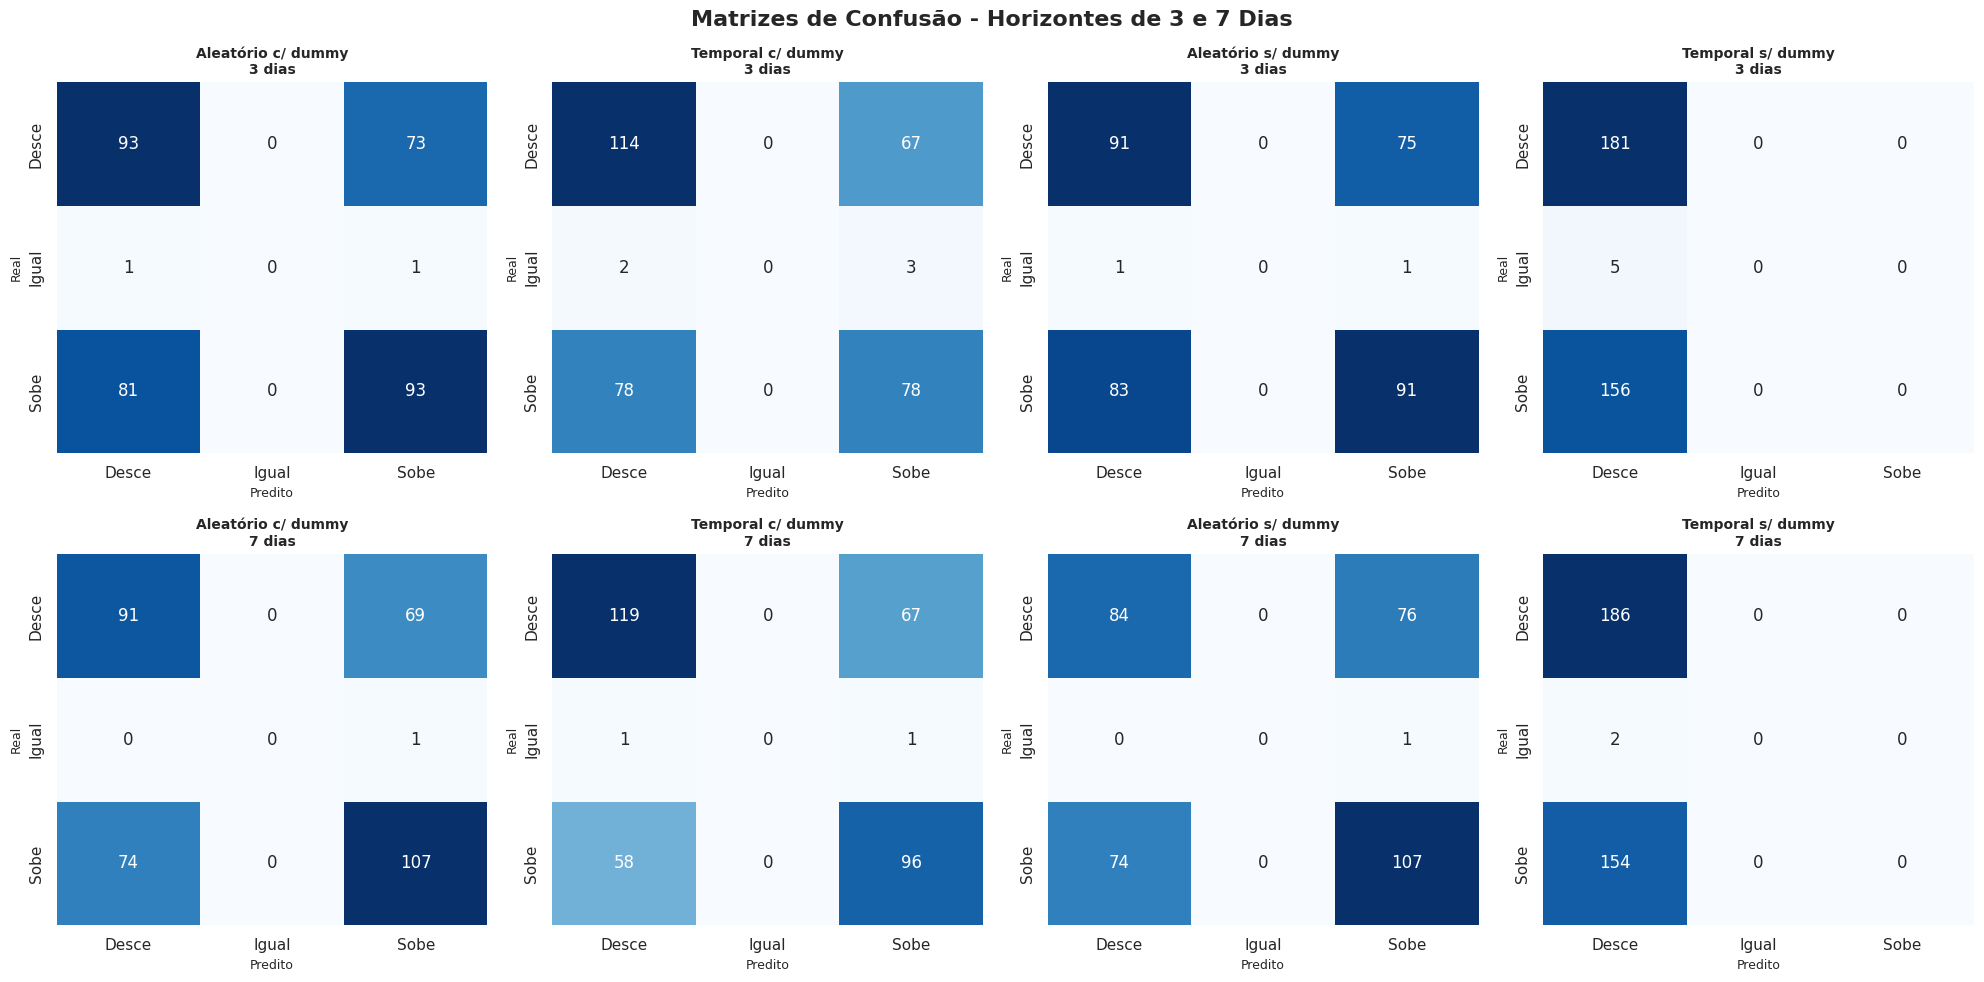

In [62]:
# Plotando matrizes de confusão para horizontes de 3 e 7 dias
plt.figure(figsize=(20, 10))

modelos = ['aleatorio_com_dummy', 'temporal_com_dummy', 'aleatorio_sem_dummy', 'temporal_sem_dummy']
titulos = ['Aleatório c/ dummy', 'Temporal c/ dummy', 'Aleatório s/ dummy', 'Temporal s/ dummy']
horizontes_grupo1 = ['3d', '7d']

for i, horizon in enumerate(horizontes_grupo1):
    if horizon in confusion_matrices:
        for j, (modelo, titulo) in enumerate(zip(modelos, titulos)):
            ax = plt.subplot(2, 4, i*4 + j + 1)
            if modelo in confusion_matrices[horizon]:
                cm = confusion_matrices[horizon][modelo]
                plot_confusion_matrix(cm, f'{titulo}\n{horizon[:-1]} dias', ax)
            else:
                plt.text(0.5, 0.5, 'Dados não\ndisponíveis', ha='center', va='center', 
                        transform=ax.transAxes, fontsize=12)
                ax.set_title(f'{titulo}\n{horizon[:-1]} dias', fontsize=10, fontweight='bold')

plt.suptitle('Matrizes de Confusão - Horizontes de 3 e 7 Dias', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

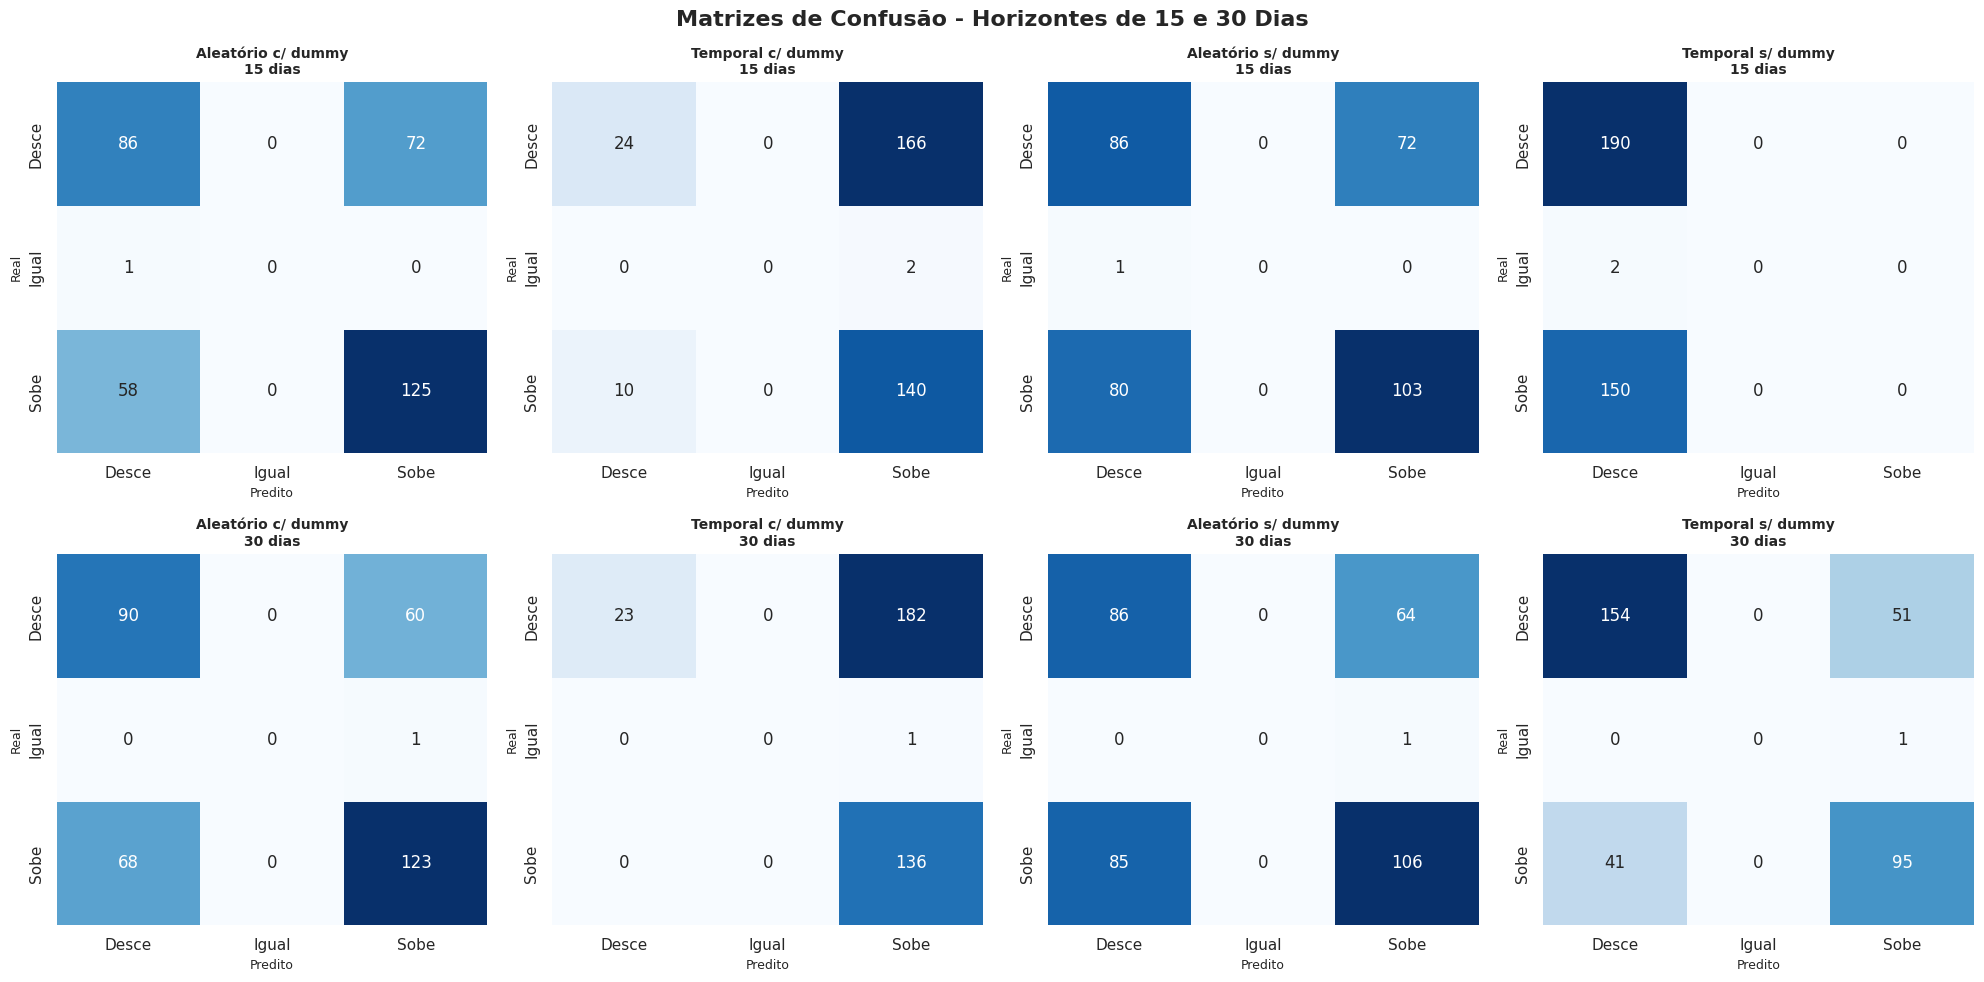

In [61]:
# Plotando matrizes de confusão para horizontes de 15 e 30 dias
plt.figure(figsize=(20, 10))

horizontes_grupo2 = ['15d', '30d']

for i, horizon in enumerate(horizontes_grupo2):
    if horizon in confusion_matrices:
        for j, (modelo, titulo) in enumerate(zip(modelos, titulos)):
            ax = plt.subplot(2, 4, i*4 + j + 1)
            if modelo in confusion_matrices[horizon]:
                cm = confusion_matrices[horizon][modelo]
                plot_confusion_matrix(cm, f'{titulo}\n{horizon[:-1]} dias', ax)
            else:
                plt.text(0.5, 0.5, 'Dados não\ndisponíveis', ha='center', va='center', 
                        transform=ax.transAxes, fontsize=12)
                ax.set_title(f'{titulo}\n{horizon[:-1]} dias', fontsize=10, fontweight='bold')

plt.suptitle('Matrizes de Confusão - Horizontes de 15 e 30 Dias', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()